# Final results for geomagnetic storm prediction

In [ ]:
import numpy as np
import pandas as pd

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.data.fetch_nasa_omni_historical import load_and_clean_nasa_omni_historical_for_years
from src.features.preprocessing import SolarWindPreprocessor

Here we ingest our training data

In [2]:
years = list(range(1995, 2024))
dfs = load_and_clean_nasa_omni_historical_for_years(years)

2026-03-22 09:06:38,559 - INFO - Found existing raw data file for year 1995 at data/raw/omni2_1995_raw.csv. Loading...
2026-03-22 09:06:38,580 - INFO - Found existing raw data file for year 1996 at data/raw/omni2_1996_raw.csv. Loading...
2026-03-22 09:06:38,591 - INFO - Found existing raw data file for year 1997 at data/raw/omni2_1997_raw.csv. Loading...
2026-03-22 09:06:38,605 - INFO - Found existing raw data file for year 1998 at data/raw/omni2_1998_raw.csv. Loading...
2026-03-22 09:06:38,614 - INFO - Found existing raw data file for year 1999 at data/raw/omni2_1999_raw.csv. Loading...
2026-03-22 09:06:38,623 - INFO - Found existing raw data file for year 2000 at data/raw/omni2_2000_raw.csv. Loading...
2026-03-22 09:06:38,632 - INFO - Found existing raw data file for year 2001 at data/raw/omni2_2001_raw.csv. Loading...
2026-03-22 09:06:38,642 - INFO - Found existing raw data file for year 2002 at data/raw/omni2_2002_raw.csv. Loading...
2026-03-22 09:06:38,651 - INFO - Found existing 

Then we preprocess the data for training by cleaning and engineering appropriate features

In [3]:
preprocessor = SolarWindPreprocessor()
preprocessed_Xs = []
preprocessed_ys = []
for df in dfs:
    (X, y) = preprocessor.preprocess(df, scale=False)
    y_bin = y >= 50
    y_bin.name = 'Is_Storm'
    # y.drop(columns=['Kp_index'], inplace=True)
    preprocessed_Xs.append(X)
    preprocessed_ys.append(y_bin)

target_col = 'Is_Storm'

2026-03-22 09:07:34,473 - INFO - Initialized SolarWindPreprocessor with standard scaler
2026-03-22 09:07:34,474 - INFO - === STARTING PREPROCESSING PIPELINE ===
2026-03-22 09:07:34,475 - INFO - Engineering features...
2026-03-22 09:07:34,481 - INFO - Features after engineering: 22
2026-03-22 09:07:34,481 - INFO - Selecting 15 features...
2026-03-22 09:07:34,487 - INFO - Selected features shape: (8760, 16)
2026-03-22 09:07:34,487 - INFO - Handling missing values with method: interpolate
2026-03-22 09:07:34,490 - INFO - Missing values reduced from 8 to 0
2026-03-22 09:07:34,492 - INFO - Features shape: (8758, 15), Target shape: (8758,)
2026-03-22 09:07:34,492 - INFO - === PREPROCESSING COMPLETE ===

2026-03-22 09:07:34,493 - INFO - === STARTING PREPROCESSING PIPELINE ===
2026-03-22 09:07:34,493 - INFO - Engineering features...
2026-03-22 09:07:34,498 - INFO - Features after engineering: 22
2026-03-22 09:07:34,498 - INFO - Selecting 15 features...
2026-03-22 09:07:34,500 - INFO - Selected

Here we train the final model across time series splits with each fold being one year

In [4]:
from xgboost import XGBClassifier

In [7]:
from src.models.train import class_weight_across_folds, train_on_temporal_splits

scale_weight =  class_weight_across_folds(preprocessed_ys)
xgbparams = {
    'max_depth':5,            
    'learning_rate':0.111,     
    'scale_pos_weight':scale_weight,
    'eval_metric':'logloss',
    'random_state':42}

model,params = (XGBClassifier,xgbparams)
xgb_models = train_on_temporal_splits(model, params, preprocessed_Xs, preprocessed_ys)
best_prob_threshold = 0.71

We evaluate the model based on its performance across the folds. 
This is important because simply evaluating across one test year is insufficient to evaluate model performance (some years have very few storms). 
Additionally, the final model is scored by using the `.predict_proba` method and only predicting a storm if the threshold is above 0.71.

/var/folders/_v/rxjyhj5s2gs85glvfgzgxpd40000gn/T/ipykernel_82701/717928981.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


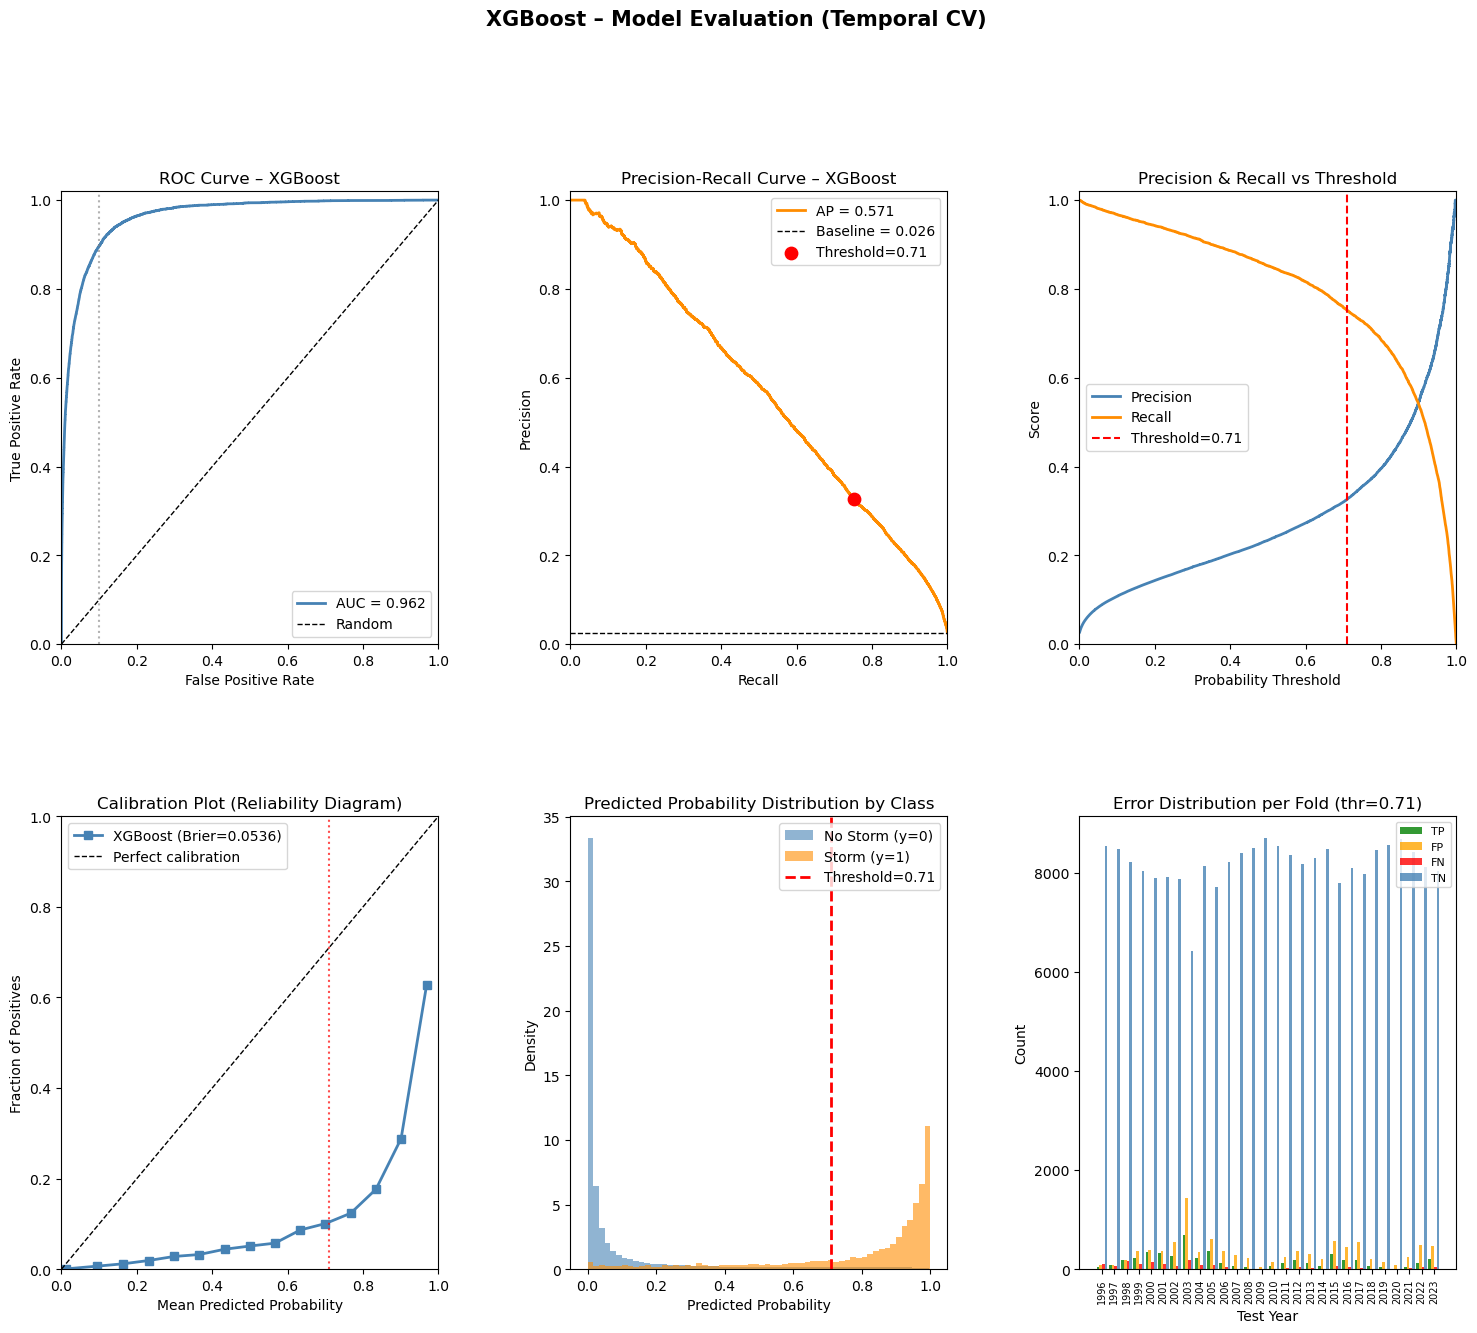


Aggregate OOF Metrics (threshold=0.7100):
  ROC-AUC        : 0.9620
  Avg Precision  : 0.5706
  Brier Score    : 0.0536
  Overall Precision: 0.3260
  Overall Recall : 0.7517


In [8]:
from src.models.train import train_on_temporal_splits, test_on_temporal_splits
from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    brier_score_loss
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec



# Collect all OOF probabilities and true labels for aggregate plots
all_probs = []
all_trues = []
all_preds_binary = []

# Also get per-fold predictions using threshold
preds = test_on_temporal_splits(xgb_models, preprocessed_Xs, preprocessed_ys, best_prob_threshold)

# Gather raw probabilities from each fold (test on last fold per model)
n_splits = len(xgb_models)
for fold_idx, model in enumerate(xgb_models):
    # Test fold is the fold right after training folds
    test_idx = fold_idx + 1  # temporal split: train on 0..fold_idx, test on fold_idx+1
    if test_idx < len(preprocessed_Xs):
        X_test = preprocessed_Xs[test_idx]
        y_test = preprocessed_ys[test_idx]
        proba = model.predict_proba(X_test)[:, 1]
        all_probs.extend(proba)
        all_trues.extend(y_test.astype(int).values)
        all_preds_binary.extend((proba >= best_prob_threshold).astype(int))

all_probs = np.array(all_probs)
all_trues = np.array(all_trues)
all_preds_binary = np.array(all_preds_binary)

# ── Figure Setup ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# ── 1. ROC Curve ──────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(all_trues, all_probs)
roc_auc = auc(fpr, tpr)
ax_roc.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax_roc.axvline(x=0.1, color='gray', linestyle=':', alpha=0.6)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve – XGBoost')
ax_roc.legend(loc='lower right')
ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])

# ── 2. Precision-Recall Curve ─────────────────────────────────────────────────
ax_pr = fig.add_subplot(gs[0, 1])
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(all_trues, all_probs)
ap = average_precision_score(all_trues, all_probs)
ax_pr.plot(recall_vals, precision_vals, color='darkorange', lw=2, label=f'AP = {ap:.3f}')
baseline = all_trues.mean()
ax_pr.axhline(y=baseline, color='k', linestyle='--', lw=1, label=f'Baseline = {baseline:.3f}')
# Mark operating threshold
op_idx = np.argmin(np.abs(thresholds_pr - best_prob_threshold))
ax_pr.scatter(recall_vals[op_idx], precision_vals[op_idx],
              color='red', zorder=5, s=80, label=f'Threshold={best_prob_threshold:.2f}')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve – XGBoost')
ax_pr.legend(loc='upper right')
ax_pr.set_xlim([0, 1]); ax_pr.set_ylim([0, 1.02])

# ── 3. Precision & Recall vs Threshold ────────────────────────────────────────
ax_thr = fig.add_subplot(gs[0, 2])
ax_thr.plot(thresholds_pr, precision_vals[:-1], color='steelblue', lw=2, label='Precision')
ax_thr.plot(thresholds_pr, recall_vals[:-1], color='darkorange', lw=2, label='Recall')
ax_thr.axvline(x=best_prob_threshold, color='red', linestyle='--', lw=1.5, label=f'Threshold={best_prob_threshold:.2f}')
ax_thr.set_xlabel('Probability Threshold')
ax_thr.set_ylabel('Score')
ax_thr.set_title('Precision & Recall vs Threshold')
ax_thr.legend()
ax_thr.set_xlim([0, 1]); ax_thr.set_ylim([0, 1.02])

# ── 4. Calibration Plot ───────────────────────────────────────────────────────
ax_cal = fig.add_subplot(gs[1, 0])
fraction_of_positives, mean_predicted_value = calibration_curve(all_trues, all_probs, n_bins=15)
brier = brier_score_loss(all_trues, all_probs)
ax_cal.plot(mean_predicted_value, fraction_of_positives,
            's-', color='steelblue', lw=2, label=f'XGBoost (Brier={brier:.4f})')
ax_cal.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax_cal.axvline(x=best_prob_threshold, color='red', linestyle=':', lw=1.5, alpha=0.7)
ax_cal.set_xlabel('Mean Predicted Probability')
ax_cal.set_ylabel('Fraction of Positives')
ax_cal.set_title('Calibration Plot (Reliability Diagram)')
ax_cal.legend()
ax_cal.set_xlim([0, 1]); ax_cal.set_ylim([0, 1])

# ── 5. Predicted Probability Distribution ─────────────────────────────────────
ax_dist = fig.add_subplot(gs[1, 1])
storm_probs = all_probs[all_trues == 1]
no_storm_probs = all_probs[all_trues == 0]
ax_dist.hist(no_storm_probs, bins=60, alpha=0.6, color='steelblue',
             density=True, label='No Storm (y=0)')
ax_dist.hist(storm_probs, bins=60, alpha=0.6, color='darkorange',
             density=True, label='Storm (y=1)')
ax_dist.axvline(x=best_prob_threshold, color='red', linestyle='--',
                lw=2, label=f'Threshold={best_prob_threshold:.2f}')
ax_dist.set_xlabel('Predicted Probability')
ax_dist.set_ylabel('Density')
ax_dist.set_title('Predicted Probability Distribution by Class')
ax_dist.legend()

# ── 6. Error Distribution (FP/FN/TP/TN per fold) ─────────────────────────────
ax_err = fig.add_subplot(gs[1, 2])
fold_labels, tps, fps, tns, fns = [], [], [], [], []

for fold_idx, model in enumerate(xgb_models):
    test_idx = fold_idx + 1
    if test_idx < len(preprocessed_Xs):
        X_test = preprocessed_Xs[test_idx]
        y_test = preprocessed_ys[test_idx].astype(int).values
        proba = model.predict_proba(X_test)[:, 1]
        y_pred = (proba >= best_prob_threshold).astype(int)
        tp = int(((y_pred == 1) & (y_test == 1)).sum())
        fp = int(((y_pred == 1) & (y_test == 0)).sum())
        tn = int(((y_pred == 0) & (y_test == 0)).sum())
        fn = int(((y_pred == 0) & (y_test == 1)).sum())
        tps.append(tp); fps.append(fp); tns.append(tn); fns.append(fn)
        fold_labels.append(f'{years[test_idx]}')

x_pos = np.arange(len(fold_labels))
width = 0.22
ax_err.bar(x_pos - 1.5*width, tps, width, label='TP', color='green', alpha=0.8)
ax_err.bar(x_pos - 0.5*width, fps, width, label='FP', color='orange', alpha=0.8)
ax_err.bar(x_pos + 0.5*width, fns, width, label='FN', color='red', alpha=0.8)
ax_err.bar(x_pos + 1.5*width, tns, width, label='TN', color='steelblue', alpha=0.8)
ax_err.set_xticks(x_pos)
ax_err.set_xticklabels(fold_labels, rotation=90, fontsize=7)
ax_err.set_xlabel('Test Year')
ax_err.set_ylabel('Count')
ax_err.set_title(f'Error Distribution per Fold (thr={best_prob_threshold:.2f})')
ax_err.legend(loc='upper right', fontsize=8)

fig.suptitle('XGBoost – Model Evaluation (Temporal CV)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\nAggregate OOF Metrics (threshold={best_prob_threshold:.4f}):")
print(f"  ROC-AUC        : {roc_auc:.4f}")
print(f"  Avg Precision  : {ap:.4f}")
print(f"  Brier Score    : {brier:.4f}")
print(f"  Overall Precision: {(all_preds_binary[all_trues==1].sum() / all_preds_binary.sum()):.4f}" if all_preds_binary.sum() > 0 else "  No positive predictions")
print(f"  Overall Recall : {(all_preds_binary[all_trues==1].sum() / all_trues.sum()):.4f}")

Here we see that the model exceeds our goal of precision >= 0.3 and recall >= 0.6. 
Additionally, the models trained with more data seem to have better performance than the ones with less data, so we would expect model performance to improve as time went on and more data was accessible.